In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# --- CONFIGURATION ---
DATA_DIR = Path('../data/dataset/2005')
DEAD_PIXEL_THRESHOLD = 0.002  # 2% threshold to flag a cube as "striped/corrupted"

def analyze_dataset_quality():
    cube_files = list(DATA_DIR.glob('cube_*.npz'))
    print(f"Analyzing {len(cube_files)} cubes in {DATA_DIR.resolve()}...\n")
    
    if not cube_files:
        print("No cubes found.")
        return

    # Tracking metrics
    analysis_results = []

    # --- SCANNING LOOP ---
    for cube_path in tqdm(cube_files, desc="Scanning Cubes"):
        try:
            with np.load(cube_path) as data:
                img = data['pixel'] # Shape: (4, 256, 256)
                
            # A "dead pixel" is exactly 0 across all 4 bands (RGB + NIR)
            dead_pixels = np.all(img == 0, axis=0)
            dead_ratio = float(np.mean(dead_pixels))
            
            analysis_results.append({
                'filename': cube_path.name,
                'path': cube_path,
                'dead_pixel_ratio': dead_ratio,
                'dead_pixel_percent': dead_ratio * 100
            })
                
        except Exception as e:
            print(f"Error reading {cube_path.name}: {e}")

    # Convert to DataFrame for easy analysis
    df = pd.DataFrame(analysis_results)
    
    # --- ANALYSIS & COUNTS ---
    total_cubes = len(df)
    corrupted_df = df[df['dead_pixel_ratio'] > DEAD_PIXEL_THRESHOLD]
    clean_df = df[df['dead_pixel_ratio'] <= DEAD_PIXEL_THRESHOLD]
    
    print("-" * 40)
    print("📊 DATASET HEALTH SUMMARY")
    print("-" * 40)
    print(f"Total Cubes Scanned:      {total_cubes}")
    print(f"Clean Cubes (<= 2% bad):  {len(clean_df)} ({len(clean_df)/total_cubes*100:.1f}%)")
    print(f"Striped Cubes (> 2% bad): {len(corrupted_df)} ({len(corrupted_df)/total_cubes*100:.1f}%)")
    
    if len(corrupted_df) > 0:
        print(f"\nAverage damage in striped cubes: {corrupted_df['dead_pixel_percent'].mean():.2f}% pixels lost per cube")
        print(f"Maximum damage in a single cube: {corrupted_df['dead_pixel_percent'].max():.2f}% pixels lost")

    # --- VISUALIZATION 1: Histogram of Damage ---
    plt.figure(figsize=(10, 4))
    plt.hist(df['dead_pixel_percent'], bins=50, color='crimson', edgecolor='black', alpha=0.7)
    plt.axvline(x=DEAD_PIXEL_THRESHOLD * 100, color='black', linestyle='--', label=f'Threshold ({DEAD_PIXEL_THRESHOLD*100}%)')
    plt.title('Distribution of Missing/Dead Pixels Across the Dataset')
    plt.xlabel('Percentage of Dead Pixels per Cube (%)')
    plt.ylabel('Number of Cubes')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- VISUALIZATION 2: Show the Top 3 Worst Cubes ---
    if len(corrupted_df) > 0:
        print("\n🖼️ VISUALIZING THE 3 WORST CUBES (Highest % of dead pixels):")
        worst_cubes = corrupted_df.nlargest(3, 'dead_pixel_percent')
        
        fig, axes = plt.subplots(1, len(worst_cubes), figsize=(15, 5))
        if len(worst_cubes) == 1: axes = [axes]
            
        for idx, (_, row) in enumerate(worst_cubes.iterrows()):
            with np.load(row['path']) as data:
                img = data['image']
            
            # Simple RGB stretch to make the image visible
            rgb = np.dstack([img[0], img[1], img[2]])
            p_hi = np.percentile(rgb[rgb > 0], 98) if np.any(rgb > 0) else 1
            rgb_vis = np.clip(rgb / p_hi, 0, 1)
            
            axes[idx].imshow(rgb_vis)
            axes[idx].set_title(f"{row['filename']}\nData Lost: {row['dead_pixel_percent']:.1f}%")
            axes[idx].axis('off')
            
        plt.tight_layout()
        plt.show()
        
    return df

# Run the analysis and optionally store the DataFrame for further pandas queries
df_stats = analyze_dataset_quality()

Analyzing 802 cubes in /Users/neerajkaroshi/Desktop/Projects/clay_LULC/data/dataset/2005...



Scanning Cubes:   0%|          | 0/802 [00:00<?, ?it/s]

Error reading cube_649.npz: 'pixel is not a file in the archive'
Error reading cube_107.npz: 'pixel is not a file in the archive'
Error reading cube_661.npz: 'pixel is not a file in the archive'
Error reading cube_675.npz: 'pixel is not a file in the archive'
Error reading cube_113.npz: 'pixel is not a file in the archive'
Error reading cube_339.npz: 'pixel is not a file in the archive'
Error reading cube_463.npz: 'pixel is not a file in the archive'
Error reading cube_305.npz: 'pixel is not a file in the archive'
Error reading cube_311.npz: 'pixel is not a file in the archive'
Error reading cube_477.npz: 'pixel is not a file in the archive'
Error reading cube_488.npz: 'pixel is not a file in the archive'
Error reading cube_259.npz: 'pixel is not a file in the archive'
Error reading cube_517.npz: 'pixel is not a file in the archive'
Error reading cube_271.npz: 'pixel is not a file in the archive'
Error reading cube_265.npz: 'pixel is not a file in the archive'
Error reading cube_503.np

KeyError: 'dead_pixel_ratio'

Scanning 802 cubes in /Users/neerajkaroshi/Desktop/Projects/clay_LULC/data/dataset/2005...



Scanning Cubes:   0%|          | 0/802 [00:00<?, ?it/s]

--------------------------------------------------
🚨 FOUND 734 STRIPED CUBES (> 2.0% Data Loss)
--------------------------------------------------
Filename        | Data Loss  | Coordinates (Lat, Lon)
--------------------------------------------------
cube_631.npz    |  49.8%     | 29.63580, 79.93856
cube_582.npz    |  49.7%     | 29.76330, 78.98410
cube_225.npz    |  49.4%     | 30.52981, 79.28860
cube_490.npz    |  48.8%     | 29.97345, 79.13904
cube_65.npz     |  47.7%     | 31.01245, 79.11916
cube_342.npz    |  47.4%     | 30.25165, 79.21363
cube_608.npz    |  47.4%     | 29.70132, 79.54096
cube_126.npz    |  47.3%     | 30.70856, 77.76227
cube_655.npz    |  47.3%     | 29.56907, 80.33567
cube_615.npz    |  45.6%     | 29.61958, 78.66978
cube_53.npz     |  45.0%     | 30.99299, 78.07424
cube_68.npz     |  44.6%     | 30.91811, 77.83555
cube_613.npz    |  44.3%     | 29.70726, 80.25537
cube_541.npz    |  44.2%     | 29.91561, 80.33338
cube_505.npz    |  43.9%     | 29.98491, 80.3329

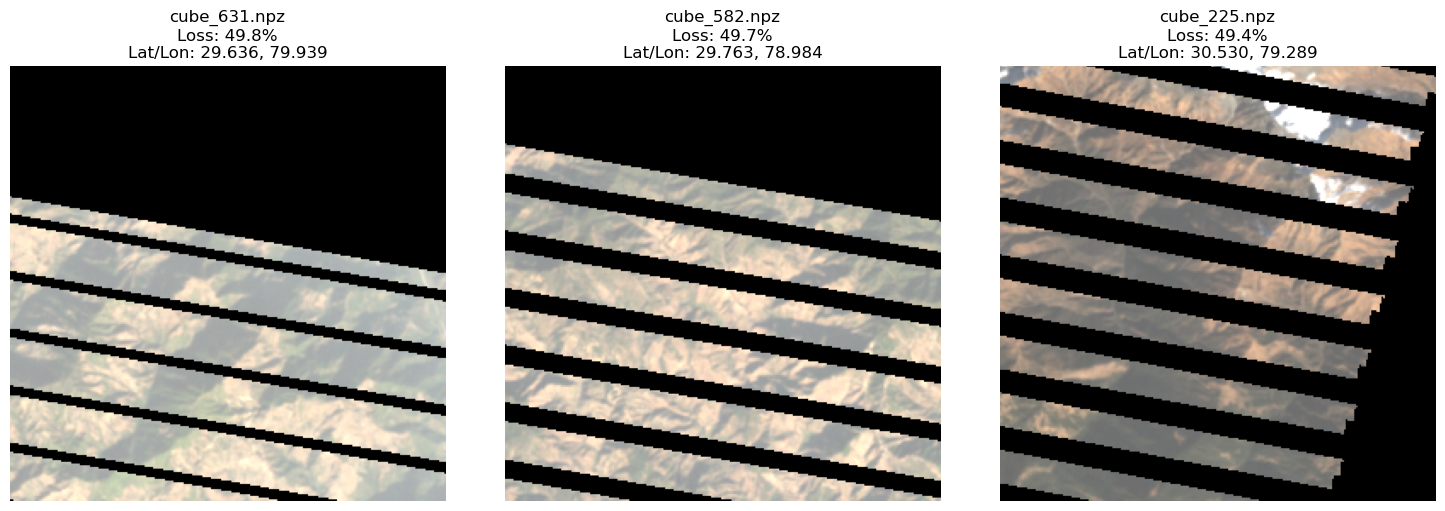

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# --- CONFIGURATION ---
DATA_DIR = Path('../data/dataset/2005/')
DEAD_PIXEL_THRESHOLD = 0.02  # 2% threshold

# --- DECODING UTILITY ---
def decode_latlon(lat_encoded, lon_encoded):
    """Reverses the sin/cos encoding to get real-world coordinates."""
    def decode_scalar_pair(pair):
        angle = np.arctan2(pair[0], pair[1])
        return (angle / (2 * np.pi)) % 1.0

    lat_norm_val = decode_scalar_pair(lat_encoded)
    lon_norm_val = decode_scalar_pair(lon_encoded)
    
    # De-normalize back to degrees
    lat_est = lat_norm_val * 180.0 - 90.0
    lon_est = lon_norm_val * 360.0 - 180.0
    
    return lat_est, lon_est

def analyze_and_locate_stripes():
    cube_files = list(DATA_DIR.glob('cube_*.npz'))
    print(f"Scanning {len(cube_files)} cubes in {DATA_DIR.resolve()}...\n")
    
    if not cube_files:
        print("No cubes found.")
        return

    analysis_results = []

    # --- SCANNING LOOP ---
    for cube_path in tqdm(cube_files, desc="Scanning Cubes"):
        try:
            with np.load(cube_path) as data:
                # Updated to use the correct keys
                img = data['pixels'] 
                lat_encoded = data['lat_norm']
                lon_encoded = data['lon_norm']
                
            # Decode coordinates using separated inputs
            lat, lon = decode_latlon(lat_encoded, lon_encoded)
                
            # Calculate dead pixels (all bands = 0)
            dead_pixels = np.all(img == 0, axis=0)
            dead_ratio = float(np.mean(dead_pixels))
            
            analysis_results.append({
                'filename': cube_path.name,
                'path': cube_path,
                'dead_pixel_ratio': dead_ratio,
                'dead_pixel_percent': dead_ratio * 100,
                'latitude': lat,
                'longitude': lon
            })
                
        except Exception as e:
            print(f"Error reading {cube_path.name}: {e}")

    df = pd.DataFrame(analysis_results)
    corrupted_df = df[df['dead_pixel_ratio'] > DEAD_PIXEL_THRESHOLD].copy()
    
    print("-" * 50)
    print(f"🚨 FOUND {len(corrupted_df)} STRIPED CUBES (> {DEAD_PIXEL_THRESHOLD*100}% Data Loss)")
    print("-" * 50)
    
    # --- PRINT COORDINATES FOR BAD CUBES ---
    if len(corrupted_df) > 0:
        # Sort by worst damage first
        corrupted_df = corrupted_df.sort_values(by='dead_pixel_percent', ascending=False)
        
        print(f"{'Filename':<15} | {'Data Loss':<10} | {'Coordinates (Lat, Lon)'}")
        print("-" * 50)
        for _, row in corrupted_df.iterrows():
            print(f"{row['filename']:<15} | {row['dead_pixel_percent']:>5.1f}%     | {row['latitude']:.5f}, {row['longitude']:.5f}")

    # --- VISUALIZE THE WORST CUBES ---
    if len(corrupted_df) > 0:
        print("\n🖼️ VISUALIZING THE WORST CUBES:")
        worst_cubes = corrupted_df.head(3)
        
        fig, axes = plt.subplots(1, len(worst_cubes), figsize=(15, 5))
        # Handle case where there is only 1 corrupted cube
        if len(worst_cubes) == 1: 
            axes = [axes]
            
        for idx, (_, row) in enumerate(worst_cubes.iterrows()):
            with np.load(row['path']) as data:
                img = data['pixels'] # Updated key
            
            rgb = np.dstack([img[0], img[1], img[2]])
            p_hi = np.percentile(rgb[rgb > 0], 98) if np.any(rgb > 0) else 1
            rgb_vis = np.clip(rgb / p_hi, 0, 1)
            
            axes[idx].imshow(rgb_vis)
            axes[idx].set_title(f"{row['filename']}\nLoss: {row['dead_pixel_percent']:.1f}%\nLat/Lon: {row['latitude']:.3f}, {row['longitude']:.3f}")
            axes[idx].axis('off')
            
        plt.tight_layout()
        plt.show()
        
    return df

# Run it
df_stats = analyze_and_locate_stripes()